## PRACTICAL 5 : Image Deblurring using Inverse and Wiener Filter

In [1]:
!pip install numpy scipy matplotlib opencv-python
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
##1 . Motion Blur Function
def motion_blur(image, kernel_size, angle):
    """Applies motion blur to an image."""

    kernel = np.zeros((kernel_size, kernel_size))
    
    # Create horizontal motion blur kernel
    kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)

    # Rotate kernel
    kernel = cv2.warpAffine(
        kernel,
        cv2.getRotationMatrix2D((kernel_size/2 - 0.5, kernel_size/2 - 0.5), angle, 1.0),
        (kernel_size, kernel_size)
    )

    # Normalize kernel
    kernel = kernel / np.sum(kernel)

    # Apply convolution
    blurred = convolve2d(image, kernel, mode='same', boundary='wrap')

    return blurred

In [4]:
## 2.Inverse Filter Function
def inverse_filter(blurred, kernel, eps):
    """Applies inverse filtering to deblur an image."""

    blurred_fft = np.fft.fft2(blurred)

    kernel_fft = np.fft.fft2(kernel, s=blurred.shape)

    # Avoid division by zero
    deblurred_fft = blurred_fft / (kernel_fft + eps)

    deblurred = np.fft.ifft2(deblurred_fft).real

    return deblurred

In [5]:
## 3.Wiener Filter Function
def wiener_filter(blurred, kernel, k):
    """Applies Wiener filtering to deblur an image."""

    blurred_fft = np.fft.fft2(blurred)

    kernel_fft = np.fft.fft2(kernel, s=blurred.shape)

    kernel_fft_conj = np.conj(kernel_fft)

    deblurred_fft = (kernel_fft_conj / (np.abs(kernel_fft)**2 + k)) * blurred_fft

    deblurred = np.fft.ifft2(deblurred_fft).real

    return deblurred

In [6]:
## 6.Load Image and Apply Motion Blur
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

kernel_size = 21
angle = 11

blurred = motion_blur(img, kernel_size, angle)

## 7.Create Blur Kernel
kernel = np.zeros((kernel_size, kernel_size))

kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)

kernel = cv2.warpAffine(
    kernel,
    cv2.getRotationMatrix2D((kernel_size/2 - 0.5, kernel_size/2 - 0.5), angle, 1.0),
    (kernel_size, kernel_size)
)

kernel = kernel / np.sum(kernel)

In [7]:
## step 8. Deblur using Inverse Filtering
deblurred_inverse = inverse_filter(blurred, kernel, 0.01)

## step 9. Deblur using Wiener Filtering
deblurred_wiener = wiener_filter(blurred, kernel, 0.01)

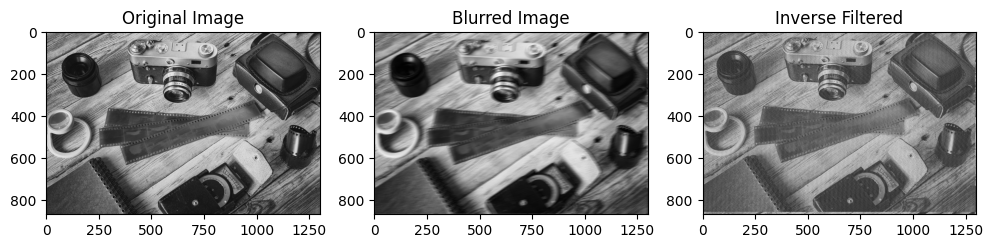

In [8]:
## step 10. Display Results (Inverse Filter)
plt.figure(figsize=(12,6))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(132)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")

plt.subplot(133)
plt.imshow(deblurred_inverse, cmap='gray')
plt.title("Inverse Filtered")

plt.show()

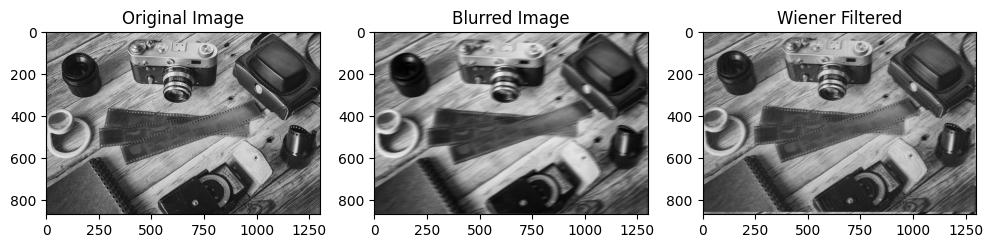

In [9]:
## step 11. Display Results (Wiener Filter)
plt.figure(figsize=(12,6))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(132)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")

plt.subplot(133)
plt.imshow(deblurred_wiener, cmap='gray')
plt.title("Wiener Filtered")

plt.show()